<a href="https://colab.research.google.com/github/tutikobi/am-trabalho-pratico-noshows/blob/main/02_modelagem_avancada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Extraindo arquivo ZIP...
Arquivos encontrados após extração: ['KaggleV2-May-2016.csv']
✅ Dataset carregado com sucesso! Iniciando limpeza e clusterização...
Limpeza concluída: 6 registros anômalos removidos.

--- Perfis de Pacientes Encontrados (Centróides) ---


,Age,WaitTime,Hypertension,Diabetes
Patient_Profile,,,,
0,30.95,10.34,0.00,0.0
1,61.37,8.69,0.82,1.0
2,59.49,10.05,1.00,0.0


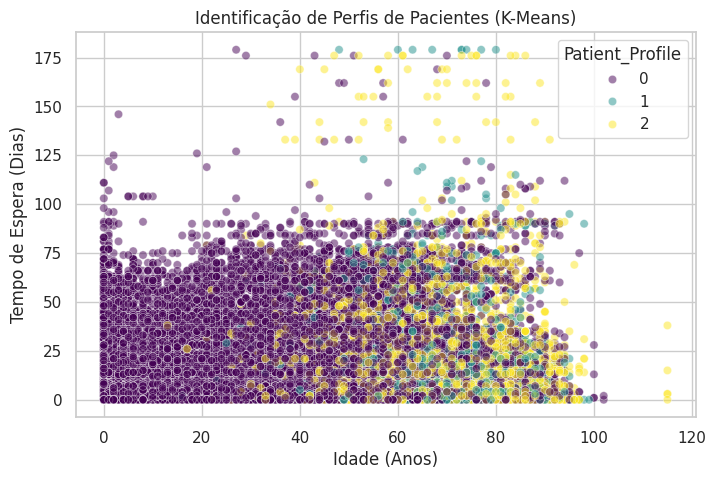

In [5]:
import pandas as pd
import numpy as np
import os
import zipfile
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

zip_path = '/content/archive.zip' # Altere para o nome exato do seu zip se for diferente
extract_dir = '/content/data'

# 1. Força a extração do arquivo ZIP (ignorando se a pasta já existe)
print("Extraindo arquivo ZIP...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# 2. Mostra na tela o que tem lá dentro para termos certeza
arquivos_extraidos = os.listdir(extract_dir)
print(f"Arquivos encontrados após extração: {arquivos_extraidos}")

# 3. Procura o arquivo CSV de forma segura
arquivos_csv = [f for f in arquivos_extraidos if f.endswith('.csv')]

if len(arquivos_csv) == 0:
    print("❌ ERRO: O arquivo .zip não contém nenhum CSV! Verifique o arquivo baixado do Kaggle.")
else:
    # Se encontrou, segue o baile!
    csv_file = arquivos_csv[0]
    df = pd.read_csv(os.path.join(extract_dir, csv_file))
    print("✅ Dataset carregado com sucesso! Iniciando limpeza e clusterização...")

    # --- ENGENHARIA DE ATRIBUTOS E LIMPEZA ---
    df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
    df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
    df['WaitTime'] = (df['AppointmentDay'].dt.normalize() - df['ScheduledDay'].dt.normalize()).dt.days
    df = df.rename(columns={'Hipertension': 'Hypertension', 'Handcap': 'Handicap', 'No-show': 'NoShow'})

    df_clean = df[(df['WaitTime'] >= 0) & (df['Age'] >= 0)].copy()
    print(f"Limpeza concluída: {len(df) - len(df_clean)} registros anômalos removidos.")

    df_clean = df_clean.drop(columns=['PatientId', 'AppointmentID', 'ScheduledDay', 'AppointmentDay'])

    # --- CLUSTERIZAÇÃO (K-MEANS) ---
    features_cluster = ['Age', 'WaitTime', 'Hypertension', 'Diabetes']
    X_cluster = df_clean[features_cluster]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cluster)

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df_clean['Patient_Profile'] = kmeans.fit_predict(X_scaled)

    # --- RESULTADOS ---
    print("\n--- Perfis de Pacientes Encontrados (Centróides) ---")
    resumo_clusters = df_clean.groupby('Patient_Profile')[features_cluster].mean().round(2)
    display(resumo_clusters)

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df_clean, x='Age', y='WaitTime', hue='Patient_Profile', palette='viridis', alpha=0.5)
    plt.title('Identificação de Perfis de Pacientes (K-Means)')
    plt.xlabel('Idade (Anos)')
    plt.ylabel('Tempo de Espera (Dias)')
    plt.show()

In [6]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import pandas as pd

# --- 1. PREPARAÇÃO PARA O XGBOOST ---
print("Preparando dados para o modelo preditivo...")
# Converter a variável alvo ('NoShow') para 0 (Compareceu) e 1 (Faltou)
df_clean['NoShow'] = df_clean['NoShow'].map({'No': 0, 'Yes': 1})

# One-Hot Encoding para variáveis categóricas (Bairros, Gênero e os Perfis que acabamos de criar)
df_encoded = pd.get_dummies(df_clean, columns=['Gender', 'Neighbourhood', 'Patient_Profile'], drop_first=True)

# Separar X (Features) e y (Target)
X = df_encoded.drop(columns=['NoShow'])
y = df_encoded['NoShow']

# --- 2. TREINAMENTO COM VALIDAÇÃO CRUZADA ESTRATIFICADA ---
print("Iniciando treinamento do XGBoost (Stratified K-Fold)...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Peso para lidar com o desbalanceamento de faltas (80/20 = proporção de ~4)
peso_classe = y.value_counts()[0] / y.value_counts()[1]
xgb_model = XGBClassifier(random_state=42, scale_pos_weight=peso_classe, eval_metric='logloss')

auc_scores = []
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    xgb_model.fit(X_train, y_train)
    # Extraindo a PROBABILIDADE de falta (e não apenas o 0 ou 1)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
    auc_scores.append(roc_auc_score(y_test, y_pred_proba))

print(f"✅ ROC-AUC Médio na Validação Cruzada: {sum(auc_scores)/len(auc_scores):.4f}")

# --- 3. MOTOR PRESCRITIVO E INTEGRAÇÃO DE SOFTWARE ---
print("\nTreinando modelo final e rodando Motor Prescritivo...")
xgb_model.fit(X, y)

# Simulando a passagem de um lote de 1000 novos agendamentos para o sistema avaliar
X_novos = X.tail(1000).copy()
X_novos['Risco_Falta_Percentual'] = xgb_model.predict_proba(X_novos)[:, 1] * 100

def motor_de_regras_n8n(risco):
    if risco >= 70.0:
        return "ALERTA VERMELHO: Acionar Webhook para Ligação Humana"
    elif risco >= 50.0:
        return "ALERTA AMARELO: Acionar Webhook para WhatsApp de Confirmação"
    else:
        return "RISCO BAIXO: Fluxo Padrão do Hospital"

X_novos['Acao_Sugerida'] = X_novos['Risco_Falta_Percentual'].apply(motor_de_regras_n8n)

# Exibir Resultados para o Artigo
print("\n--- Ações Recomendadas pelo Sistema Automático (Lote de 1000 pacientes) ---")
display(X_novos['Acao_Sugerida'].value_counts().to_frame())

print("\n--- Top 5 Pacientes Críticos Identificados (Lista de Triagem) ---")
pacientes_criticos = X_novos[X_novos['Risco_Falta_Percentual'] >= 70.0][['Age', 'WaitTime', 'Risco_Falta_Percentual', 'Acao_Sugerida']]
display(pacientes_criticos.head(5))

Preparando dados para o modelo preditivo...
Iniciando treinamento do XGBoost (Stratified K-Fold)...
✅ ROC-AUC Médio na Validação Cruzada: 0.7375

Treinando modelo final e rodando Motor Prescritivo...

--- Ações Recomendadas pelo Sistema Automático (Lote de 1000 pacientes) ---


,count
Acao_Sugerida,
ALERTA AMARELO: Acionar Webhook para WhatsApp de Confirmação,510
RISCO BAIXO: Fluxo Padrão do Hospital,416
ALERTA VERMELHO: Acionar Webhook para Ligação Humana,74



--- Top 5 Pacientes Críticos Identificados (Lista de Triagem) ---


,Age,WaitTime,Risco_Falta_Percentual,Acao_Sugerida
109552,17,2,74.066338,ALERTA VERMELHO: Acionar Webhook para Ligação ...
109560,13,2,74.095551,ALERTA VERMELHO: Acionar Webhook para Ligação ...
109608,32,2,77.022240,ALERTA VERMELHO: Acionar Webhook para Ligação ...
109610,23,2,71.783127,ALERTA VERMELHO: Acionar Webhook para Ligação ...
109617,13,2,75.855362,ALERTA VERMELHO: Acionar Webhook para Ligação ...


Calculando os valores SHAP (isso pode levar um minuto)...

✅ Gráfico gerado e salvo com sucesso em 'assets/shap_summary.png'!


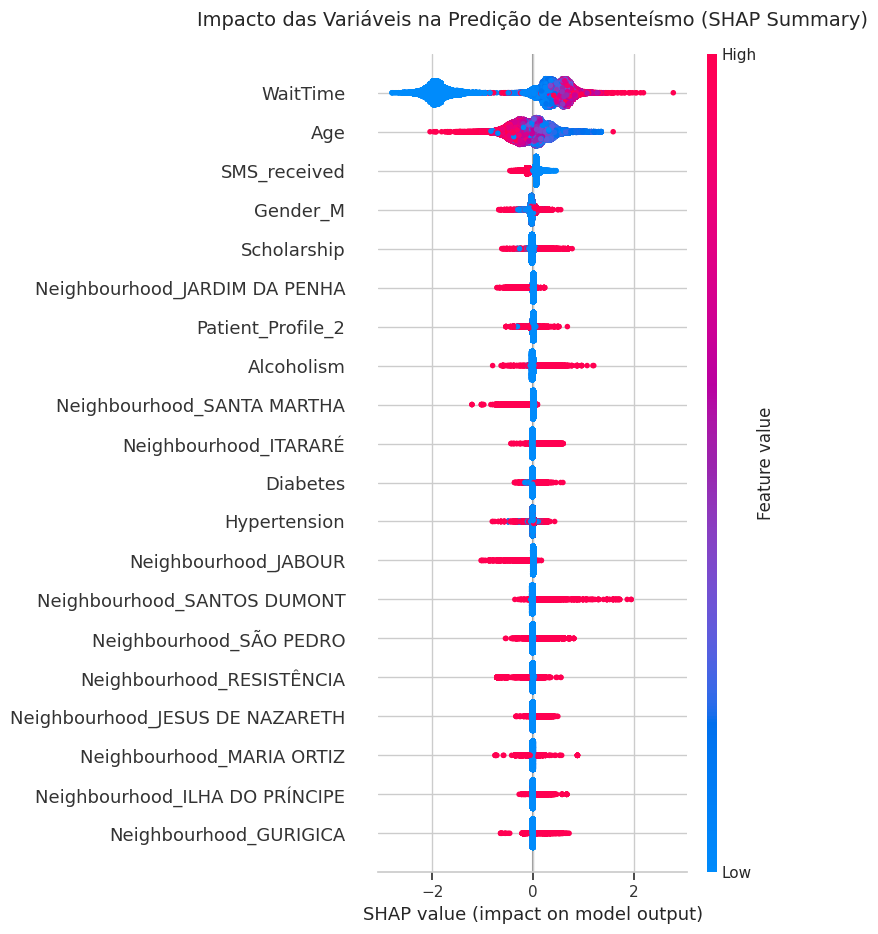

In [8]:
!pip install shap

import shap
import matplotlib.pyplot as plt
import os

print("Calculando os valores SHAP (isso pode levar um minuto)...")
# Inicializa o explainer do SHAP com o nosso XGBoost
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)

# Gera o gráfico global de impacto
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, show=False)

# Ajustes de formatação para o artigo acadêmico
plt.title('Impacto das Variáveis na Predição de Absenteísmo (SHAP Summary)', fontsize=14, pad=20)
plt.tight_layout()

# --- A CORREÇÃO ESTÁ AQUI ---
# Cria a pasta 'assets' no Colab caso ela não exista
if not os.path.exists('assets'):
    os.makedirs('assets')

# Agora sim, salva a imagem na pasta assets
plt.savefig('assets/shap_summary.png', dpi=300, bbox_inches='tight')
print("\n✅ Gráfico gerado e salvo com sucesso em 'assets/shap_summary.png'!")
plt.show()